In [26]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
BASE_DIR = Path.cwd().parent if Path.cwd().name.lower() == "notebooks" else Path.cwd()

DADOS_BRASIL = BASE_DIR / "dados" / "brasil"
DADOS_MUNDO = BASE_DIR / "dados" / "mundo"
RESULTADOS = BASE_DIR / "resultados"

FIGURAS = RESULTADOS / "figuras"
TABELAS = RESULTADOS / "tabelas"

FIGURAS.mkdir(parents=True, exist_ok=True)
TABELAS.mkdir(parents=True, exist_ok=True)

plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["font.family"] = "DejaVu Serif"
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

from mlxtend.frequent_patterns import apriori, association_rules

ARQ_NASCIMENTOS = DADOS_BRASIL / "ano_nascimento.csv"
ARQ_IDADE = DADOS_BRASIL / "idade_mae.csv"
ARQ_INSTRUCAO = DADOS_BRASIL / "instruçao_mae.csv"
ARQ_PRE_NATAL = DADOS_BRASIL / "pre-natal.csv"
ARQ_PARTO = DADOS_BRASIL / "tipo_parto.csv"

Pasta base: c:\Users\natal\OneDrive\Área de Trabalho\mineracao_dados_natalidade
Dados Brasil: c:\Users\natal\OneDrive\Área de Trabalho\mineracao_dados_natalidade\dados\brasil
Dados Mundo: c:\Users\natal\OneDrive\Área de Trabalho\mineracao_dados_natalidade\dados\mundo
Resultados: c:\Users\natal\OneDrive\Área de Trabalho\mineracao_dados_natalidade\resultados


In [28]:
def salvar_tabela_como_imagem(df, nome_arquivo, titulo=None, largura=12, altura=4, fonte=10):
    """
    Salva um DataFrame como imagem PNG para usar no relatório.
    """
    fig, ax = plt.subplots(figsize=(largura, altura))
    ax.axis("off")

    tabela = ax.table(
        cellText=df.values,
        colLabels=df.columns,
        cellLoc="center",
        colLoc="center",
        loc="center"
    )

    tabela.auto_set_font_size(False)
    tabela.set_fontsize(fonte)
    tabela.scale(1.2, 1.4)

    if titulo:
        plt.title(titulo, fontsize=13, weight="bold", pad=15)

    plt.tight_layout()
    plt.savefig(FIGURAS / nome_arquivo, dpi=300, bbox_inches="tight")
    plt.show()

In [29]:
def ler_datasus(caminho):
    df = pd.read_csv(
        caminho,
        sep=";",
        encoding="latin1",
        skiprows=3,
        dtype=str
    )
    df = df.dropna(how="all")
    df = df.loc[:, ~df.columns.str.contains("^Unnamed")]
    return df

def limpar_nome_uf(valor):
    return str(valor).replace("..", "").strip()

def converter_numero(serie):
    return pd.to_numeric(
        serie.astype(str)
        .str.replace(".", "", regex=False)
        .str.replace(",", ".", regex=False)
        .replace("-", np.nan),
        errors="coerce"
    )

def preparar_datasus_por_uf(caminho):
    df = ler_datasus(caminho)
    col_uf = "Região/Unidade da Federação"
    df[col_uf] = df[col_uf].apply(limpar_nome_uf)

    excluir = [
        "Região Norte", "Região Nordeste", "Região Sudeste",
        "Região Sul", "Região Centro-Oeste", "Total", "nan"
    ]
    df = df[~df[col_uf].isin(excluir)].copy()
    df = df.rename(columns={col_uf: "UF"})

    for col in df.columns:
        if col != "UF":
            df[col] = converter_numero(df[col])
    return df

def proporcao(df, numerador, denominador="Total"):
    return df[numerador] / df[denominador] * 100

In [30]:
# Nascimentos por UF e ano
nasc = preparar_datasus_por_uf(ARQ_NASCIMENTOS)
anos = [str(ano) for ano in range(2000, 2025)]
nasc = nasc[["UF"] + anos].copy()

base = nasc[["UF", "2000", "2024"]].copy()
base["Queda_percentual"] = ((base["2000"] - base["2024"]) / base["2000"]) * 100

# Idade da mãe
idade = preparar_datasus_por_uf(ARQ_IDADE)
idade["Mae_30_34"] = proporcao(idade, "30 a 34 anos")
idade["Mae_35_39"] = proporcao(idade, "35 a 39 anos")
idade = idade[["UF", "Mae_30_34", "Mae_35_39"]]

# Instrução da mãe
instrucao = preparar_datasus_por_uf(ARQ_INSTRUCAO)
instrucao["Instrucao_12_mais"] = proporcao(instrucao, "12 anos e mais")
instrucao = instrucao[["UF", "Instrucao_12_mais"]]

# Consultas pré-natal
prenatal = preparar_datasus_por_uf(ARQ_PRE_NATAL)
prenatal["Pre_natal_7_mais"] = proporcao(prenatal, "7 ou mais consultas")
prenatal = prenatal[["UF", "Pre_natal_7_mais"]]

# Tipo de parto
parto = preparar_datasus_por_uf(ARQ_PARTO)
parto["Cesarea"] = proporcao(parto, "Cesário")
parto = parto[["UF", "Cesarea"]]

# União das bases
base_assoc = (
    base
    .merge(idade, on="UF", how="inner")
    .merge(instrucao, on="UF", how="inner")
    .merge(prenatal, on="UF", how="inner")
    .merge(parto, on="UF", how="inner")
)

base_assoc.to_csv(TABELAS / "base_associacao_variaveis_uf_2000_2024.csv", index=False, encoding="utf-8-sig")
base_assoc.head()

,UF,2000,2024,Queda_percentual,Mae_30_34,Mae_35_39,Instrucao_12_mais,Pre_natal_7_mais,Cesarea
0,Rondônia,31307.0,21716.0,30.635321,14.376707,6.290258,14.170719,51.109390,60.638354
1,Acre,15228.0,13101.0,13.967691,13.848289,7.154202,11.378238,36.153322,35.311389
2,Amazonas,67646.0,65950.0,2.507170,13.562784,6.839980,9.811204,38.276261,35.137902
3,Roraima,9744.0,12090.0,-24.076355,14.262397,7.148313,14.181326,40.871749,32.109579
4,Pará,126340.0,118566.0,6.153237,12.200850,5.600722,9.883527,39.818082,42.649223


In [31]:
variaveis = [
    "Queda_percentual",
    "Mae_30_34",
    "Mae_35_39",
    "Instrucao_12_mais",
    "Pre_natal_7_mais",
    "Cesarea"
]

base_binaria = pd.DataFrame()
base_binaria["UF"] = base_assoc["UF"]

nomes_binarios = {
    "Queda_percentual": "Queda_nascimento_alta",
    "Mae_30_34": "Mae_30_34_alta",
    "Mae_35_39": "Mae_35_39_alta",
    "Instrucao_12_mais": "Instrucao_12_mais_alta",
    "Pre_natal_7_mais": "Pre_natal_7_mais_alto",
    "Cesarea": "Cesarea_alta"
}

for var in variaveis:
    mediana = base_assoc[var].median()
    base_binaria[nomes_binarios[var]] = base_assoc[var] >= mediana
    print(f"{var}: mediana = {mediana:.2f}")

base_binaria.to_csv(TABELAS / "base_binaria_apriori_uf_2000_2024.csv", index=False, encoding="utf-8-sig")
base_binaria.head()

Queda_percentual: mediana = 26.46
Mae_30_34: mediana = 16.50
Mae_35_39: mediana = 8.10
Instrucao_12_mais: mediana = 14.18
Pre_natal_7_mais: mediana = 55.44
Cesarea: mediana = 49.63


,UF,Queda_nascimento_alta,Mae_30_34_alta,Mae_35_39_alta,Instrucao_12_mais_alta,Pre_natal_7_mais_alto,Cesarea_alta
0,Rondônia,True,False,False,False,False,True
1,Acre,False,False,False,False,False,False
2,Amazonas,False,False,False,False,False,False
3,Roraima,False,False,False,True,False,False
4,Pará,False,False,False,False,False,False


In [32]:
transacoes = base_binaria.drop(columns="UF")

itemsets = apriori(
    transacoes,
    min_support=0.25,
    use_colnames=True
)

regras = association_rules(
    itemsets,
    metric="confidence",
    min_threshold=0.60
)

# Organização para leitura
regras["antecedents"] = regras["antecedents"].apply(lambda x: ", ".join(list(x)))
regras["consequents"] = regras["consequents"].apply(lambda x: ", ".join(list(x)))

regras = regras.sort_values(
    by=["lift", "confidence", "support"],
    ascending=False
)

regras.to_csv(TABELAS / "regras_associacao_completas_uf_2000_2024.csv", index=False, encoding="utf-8-sig")

regras[["antecedents", "consequents", "support", "confidence", "lift"]].head(20)

,antecedents,consequents,support,confidence,lift
62,"Cesarea_alta, Pre_natal_7_mais_alto","Mae_30_34_alta, Instrucao_12_mais_alta",0.270270,0.833333,3.083333
63,"Mae_30_34_alta, Instrucao_12_mais_alta","Cesarea_alta, Pre_natal_7_mais_alto",0.270270,1.000000,3.083333
60,"Cesarea_alta, Mae_30_34_alta","Instrucao_12_mais_alta, Pre_natal_7_mais_alto",0.270270,0.833333,2.803030
64,"Mae_30_34_alta, Pre_natal_7_mais_alto","Cesarea_alta, Instrucao_12_mais_alta",0.270270,0.833333,2.803030
61,"Cesarea_alta, Instrucao_12_mais_alta","Mae_30_34_alta, Pre_natal_7_mais_alto",0.270270,0.909091,2.803030
65,"Instrucao_12_mais_alta, Pre_natal_7_mais_alto","Cesarea_alta, Mae_30_34_alta",0.270270,0.909091,2.803030
50,"Cesarea_alta, Instrucao_12_mais_alta",Pre_natal_7_mais_alto,0.297297,1.000000,2.642857
52,"Instrucao_12_mais_alta, Pre_natal_7_mais_alto",Cesarea_alta,0.297297,1.000000,2.642857
27,"Mae_35_39_alta, Cesarea_alta",Mae_30_34_alta,0.270270,1.000000,2.642857
32,"Mae_30_34_alta, Instrucao_12_mais_alta",Pre_natal_7_mais_alto,0.270270,1.000000,2.642857


In [33]:
regras_queda = regras[
    regras["consequents"].str.contains("Queda_nascimento_alta") |
    regras["antecedents"].str.contains("Queda_nascimento_alta")
].copy()

regras_queda = regras_queda.sort_values(
    by=["lift", "confidence", "support"],
    ascending=False
)

regras_queda.to_csv(TABELAS / "principais_regras_queda_nascimento_uf_2000_2024.csv", index=False, encoding="utf-8-sig")

regras_queda[["antecedents", "consequents", "support", "confidence", "lift"]].head(15)

,antecedents,consequents,support,confidence,lift
0,Mae_35_39_alta,Queda_nascimento_alta,0.297297,0.785714,2.076531
1,Queda_nascimento_alta,Mae_35_39_alta,0.297297,0.785714,2.076531


In [34]:
tabela_final = regras_queda[["antecedents", "consequents", "support", "confidence", "lift"]].head(8).copy()

tabela_final = tabela_final.rename(columns={
    "antecedents": "Antecedente",
    "consequents": "Consequente",
    "support": "Suporte",
    "confidence": "Confiança",
    "lift": "Lift"
})

for col in ["Suporte", "Confiança", "Lift"]:
    tabela_final[col] = tabela_final[col].round(3)

tabela_final.to_csv(TABELAS / "tabela_final_regras_relatorio.csv", index=False, encoding="utf-8-sig")
tabela_final

,Antecedente,Consequente,Suporte,Confiança,Lift
0,Mae_35_39_alta,Queda_nascimento_alta,0.297,0.786,2.077
1,Queda_nascimento_alta,Mae_35_39_alta,0.297,0.786,2.077


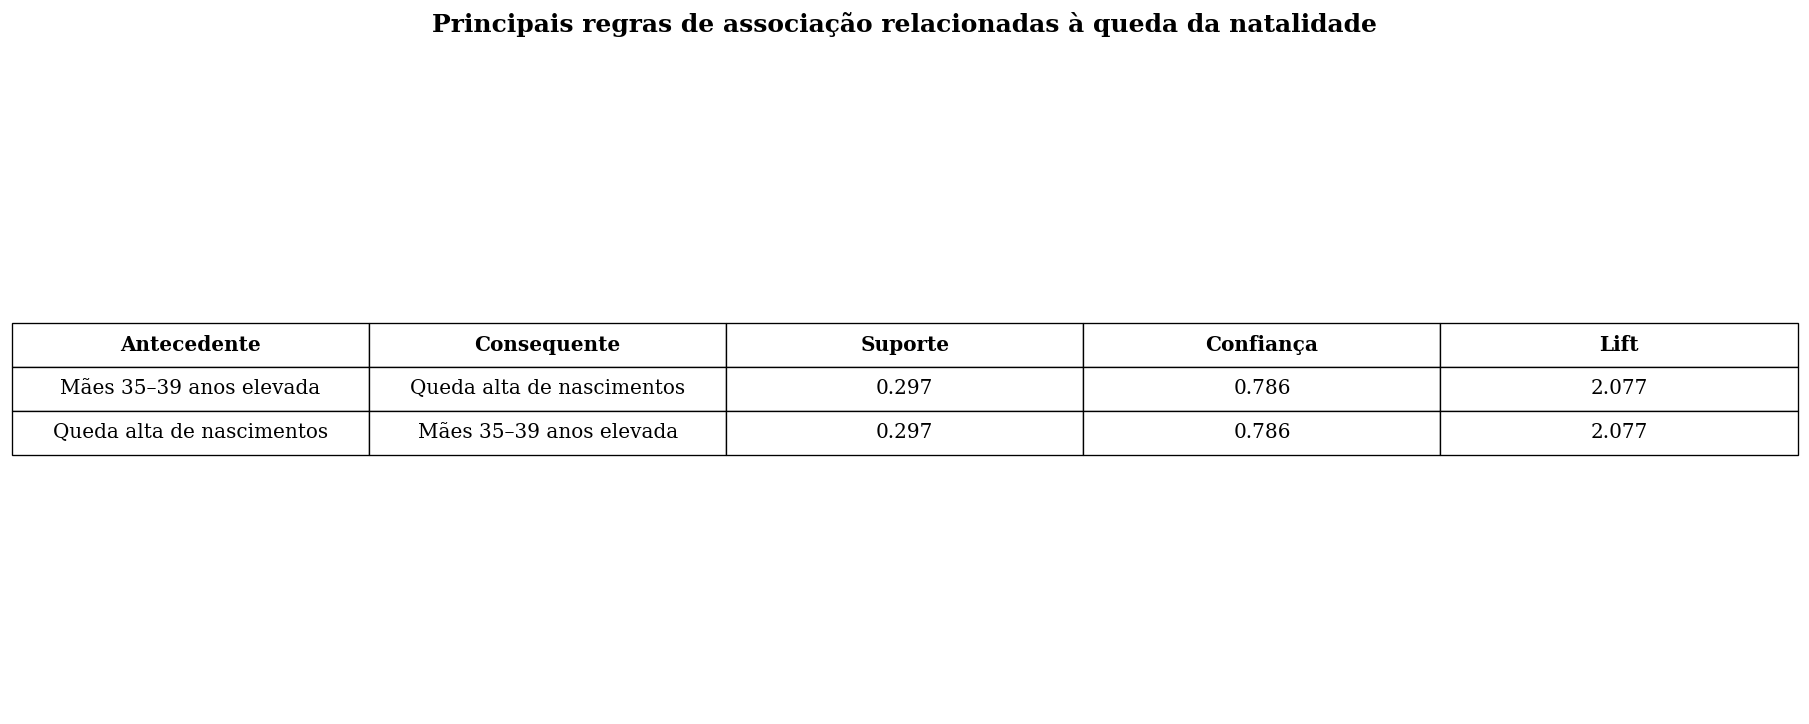

In [35]:
import textwrap

tabela_regras_imagem = tabela_final.copy()

substituicoes = {
    "Queda_nascimento_alta": "Queda alta de nascimentos",
    "Mae_30_34_alta": "Mães 30–34 anos elevada",
    "Mae_35_39_alta": "Mães 35–39 anos elevada",
    "Instrucao_12_mais_alta": "Instrução 12 anos ou mais elevada",
    "Pre_natal_7_mais_alto": "Pré-natal 7+ consultas elevado",
    "Cesarea_alta": "Cesárea elevada"
}

for antigo, novo in substituicoes.items():
    tabela_regras_imagem["Antecedente"] = tabela_regras_imagem["Antecedente"].str.replace(antigo, novo, regex=False)
    tabela_regras_imagem["Consequente"] = tabela_regras_imagem["Consequente"].str.replace(antigo, novo, regex=False)

# Quebra linhas para não ficar tudo espremido
tabela_regras_imagem["Antecedente"] = tabela_regras_imagem["Antecedente"].apply(
    lambda x: "\n".join(textwrap.wrap(str(x), width=28))
)

tabela_regras_imagem["Consequente"] = tabela_regras_imagem["Consequente"].apply(
    lambda x: "\n".join(textwrap.wrap(str(x), width=28))
)

fig, ax = plt.subplots(figsize=(16, 7))
ax.axis("off")

tabela = ax.table(
    cellText=tabela_regras_imagem.values,
    colLabels=tabela_regras_imagem.columns,
    cellLoc="center",
    colLoc="center",
    loc="center"
)

tabela.auto_set_font_size(False)
tabela.set_fontsize(12)
tabela.scale(1.2, 2.2)

# Cabeçalho em negrito
for (linha, coluna), celula in tabela.get_celld().items():
    if linha == 0:
        celula.set_text_props(weight="bold")
    celula.set_linewidth(0.8)

plt.title(
    "Principais regras de associação relacionadas à queda da natalidade",
    fontsize=15,
    weight="bold",
    pad=20
)

plt.savefig(
    FIGURAS / "tabela_2_regras_associacao.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()